## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import torch
import pickle

sys.path.insert(0, "../../../Mamoth")
sys.path.insert(0, "../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

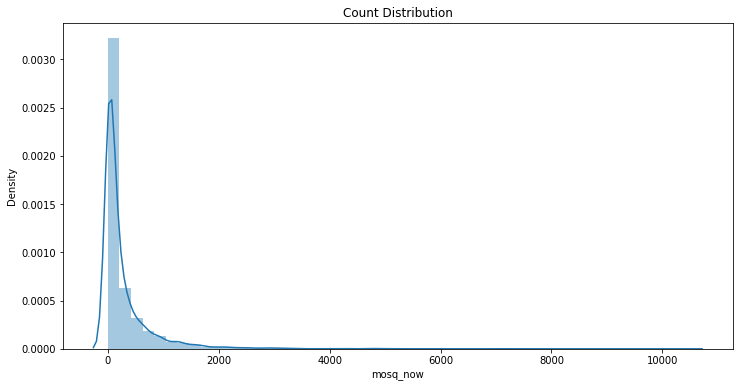

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

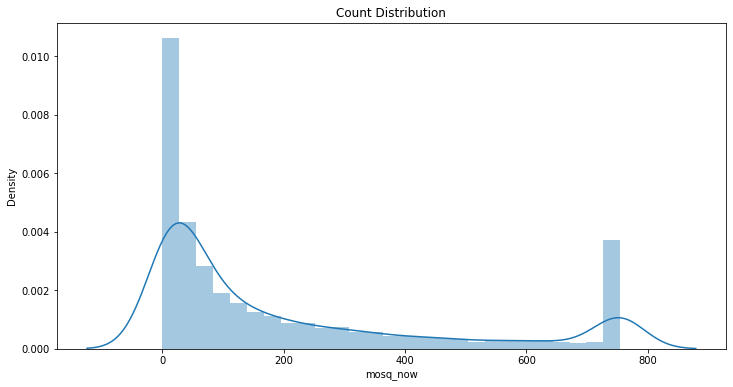

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

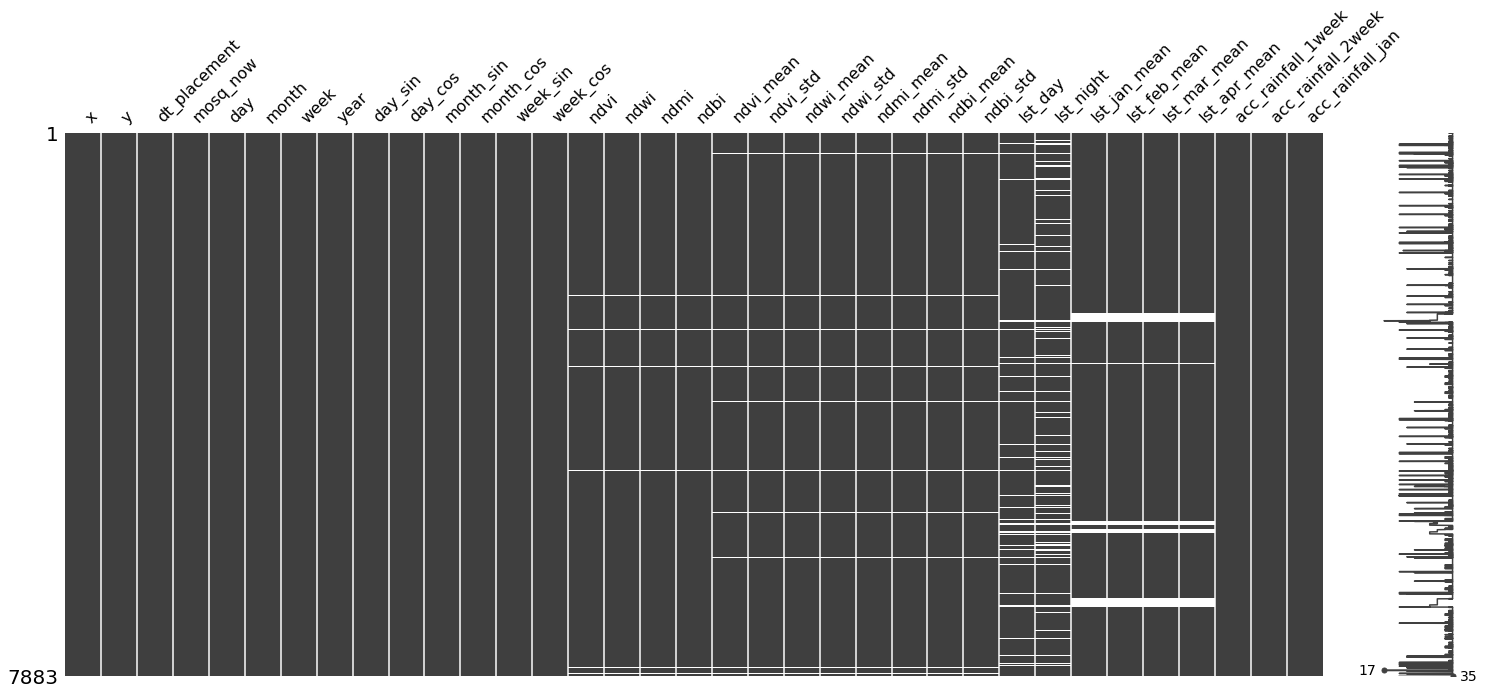

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

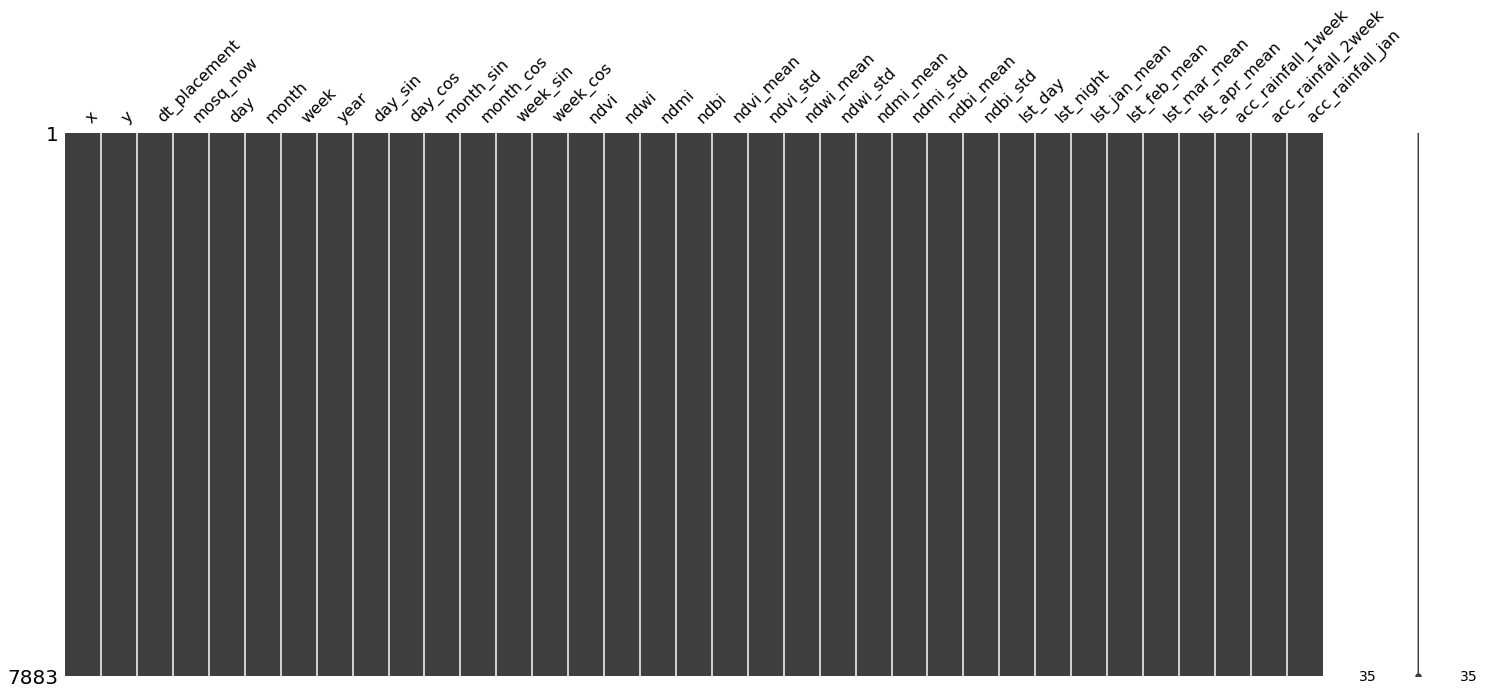

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)


In [19]:
len(train_X[0])

33

Epoch 001: | Train Loss: 20.42516 | Val Loss: 23.86330 | Train Acc: 2.782| Val Acc: 2.454
Epoch 002: | Train Loss: 18.43058 | Val Loss: 24.29251 | Train Acc: 2.231| Val Acc: 1.951
Epoch 003: | Train Loss: 18.34028 | Val Loss: 26.06437 | Train Acc: 2.214| Val Acc: 2.129
Epoch 004: | Train Loss: 18.11663 | Val Loss: 26.94345 | Train Acc: 2.151| Val Acc: 2.197
Epoch 005: | Train Loss: 18.03929 | Val Loss: 24.43137 | Train Acc: 2.143| Val Acc: 2.038
Epoch 006: | Train Loss: 17.63644 | Val Loss: 24.03464 | Train Acc: 2.083| Val Acc: 1.972
Epoch 007: | Train Loss: 17.33758 | Val Loss: 24.74099 | Train Acc: 2.024| Val Acc: 1.991
Epoch 008: | Train Loss: 17.08134 | Val Loss: 24.91579 | Train Acc: 2.010| Val Acc: 2.051
Epoch 009: | Train Loss: 17.05812 | Val Loss: 23.82043 | Train Acc: 2.008| Val Acc: 1.973
Epoch 010: | Train Loss: 16.88932 | Val Loss: 24.16700 | Train Acc: 1.986| Val Acc: 2.041
Epoch 011: | Train Loss: 16.78707 | Val Loss: 23.76906 | Train Acc: 1.997| Val Acc: 2.066
Epoch 012:

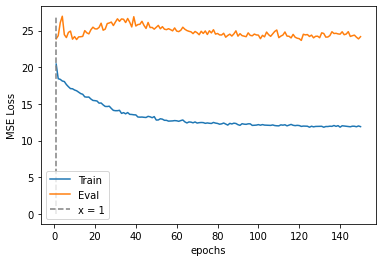

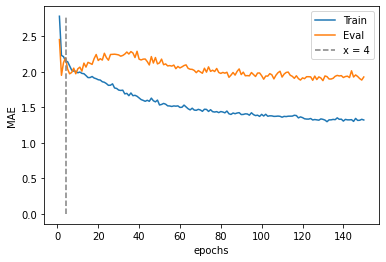

In [20]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [21]:
metrics(train, test, threshold=30)

MAE on train set:  128.9546676447543
min prediction: 1
max prediction: 1344

MAE on test set:  145.49939693508583
Error ⩽ 30: 22.81 %
min prediction: 1
max prediction: 978


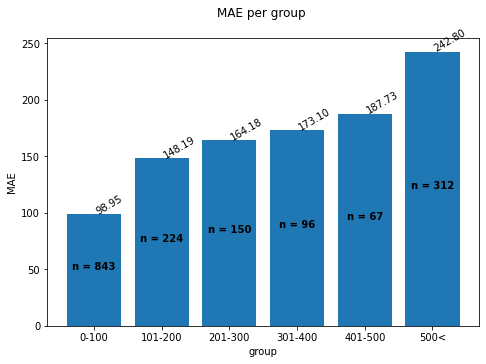

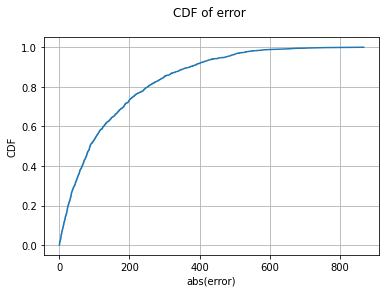

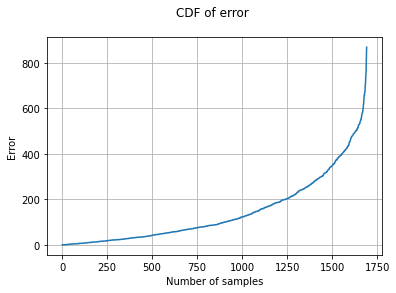

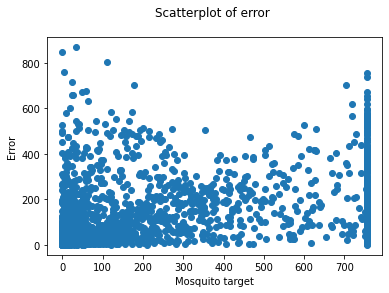

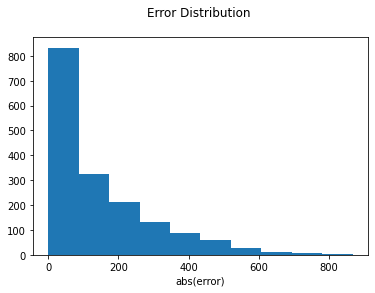

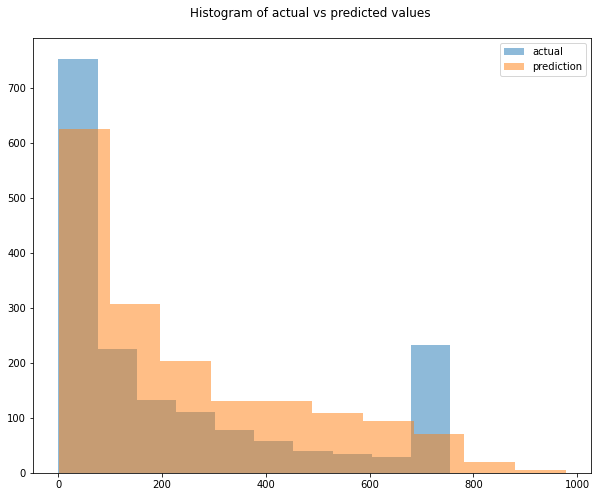

In [22]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.72241 | Val Loss: 1.01624 | Train Acc: 1.564| Val Acc: 0.633
Epoch 002: | Train Loss: 13.47505 | Val Loss: 0.70184 | Train Acc: 1.536| Val Acc: 0.633
Epoch 003: | Train Loss: 13.59518 | Val Loss: 0.00053 | Train Acc: 1.552| Val Acc: 0.367
Epoch 004: | Train Loss: 13.52530 | Val Loss: 0.52344 | Train Acc: 1.551| Val Acc: 0.633
Epoch 005: | Train Loss: 13.17278 | Val Loss: 0.33448 | Train Acc: 1.494| Val Acc: 0.633
Epoch 006: | Train Loss: 13.26267 | Val Loss: 0.85397 | Train Acc: 1.501| Val Acc: 0.633
Epoch 007: | Train Loss: 13.20612 | Val Loss: 2.18655 | Train Acc: 1.493| Val Acc: 1.633
Epoch 008: | Train Loss: 13.26385 | Val Loss: 1.51670 | Train Acc: 1.491| Val Acc: 1.633
Epoch 009: | Train Loss: 12.98908 | Val Loss: 2.85174 | Train Acc: 1.466| Val Acc: 1.633
Epoch 010: | Train Loss: 12.87954 | Val Loss: 2.45433 | Train Acc: 1.450| Val Acc: 1.633
Epoch 011: | Train Loss: 12.92478 | Val Loss: 2.43937 | Train Acc: 1.455| Val Acc: 1.633
Epoch 012: | Train Lo

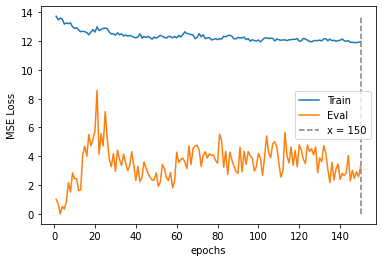

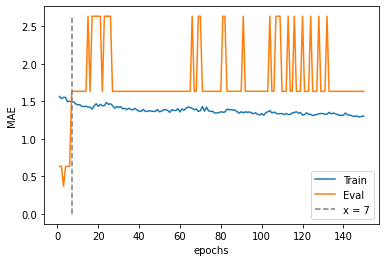

In [23]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [24]:
# torch.save(model.state_dict(), f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_Model.pt')
# torch.save(model, f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_Model.pth')

In [25]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'wb'))